# Topic Modeling: LDA and BERTopic
Welcome to the topic modeling notebook! Since you're new to Natural Language Processing (NLP), we'll walk through this step-by-step. 

**Topic Modeling** is a technique used to discover hidden themes (topics) in large amounts of text data. You can think of it as automatically grouping documents into categories based on the words they contain.

In this notebook, we'll explore two popular topic modeling techniques on the Thai Constitution dataset:
1. **LDA (Latent Dirichlet Allocation):** A traditional, statistical approach.
2. **BERTopic:** A modern, deep-learning approach that understands the *context* of words.


In [1]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Setup Thai font to fix missing glyphs in plots.
font_path = '../../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
print(f"Font loaded: {font_prop.get_name()}")


Font loaded: LINE Seed Sans TH


In [2]:
# Install required libraries
# AttaCut is included because the upstream preprocessing used by basic_eda tokenizes with engine='attacut'.
%pip install pandas numpy scikit-learn pythainlp attacut bertopic sentence-transformers matplotlib


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of nptyping to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of nptyping to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 737.1 kB/s  0:00:01 eta 0:00:01
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13782 sha256=0c2da2772e7aac6d9ff76165ad4dd458dcdb6322ba38014caaa367cb664d5c91
  Stored in directory: /Users/natthawat/Library/Caches/pip/wheels/79/6f/5f/26c3d1a144117ef52122d67c32b9f3c297c3dec4fea00a31ac
Successfully built docopt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [attacut]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: y

In [3]:
import pandas as pd
import ast
import warnings
warnings.filterwarnings('ignore')

# We will need these later
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


## 1. Data Loading and Preparation
This notebook uses the newer `sections_v2.csv` structure from `03_data_preparation/output`. The file stores one row per section with raw text, so we normalize the identifier columns and recreate the same Thai tokenization used upstream by `basic_eda.ipynb` via `data/preprocessed_data.csv`: AttaCut tokenization, Thai stopword removal, whitespace stripping, and punctuation/symbol filtering.


In [4]:
# Load the newer section-level dataset and tokenize with the same logic used for basic_eda's preprocessed tokens.
import re
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize

df = pd.read_csv('../../output/sections_v2.csv', encoding='utf-8-sig', engine='python', on_bad_lines='skip')

# Normalize the sections_v2 schema to the column names expected below.
df = df.rename(columns={
    'doc_id': 'constitution_id',
})

df['text'] = df['text'].fillna('').astype(str)
df = df[df['text'].str.strip().ne('')].copy()

stopwords = set(thai_stopwords())

def preprocess_thai(text):
    tokens = word_tokenize(text, engine='attacut')

    clean_tokens = []
    for token in tokens:
        token = token.strip()
        if (
            token
            and token not in stopwords
            and not re.match(r'^[\W_]+$', token)
        ):
            clean_tokens.append(token)

    return clean_tokens

df['tokens'] = df['text'].apply(preprocess_thai)
df['joined_tokens'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))
df['word_count'] = df['tokens'].apply(len)
df = df[df['word_count'] > 0].reset_index(drop=True)

display_columns = ['section_id', 'constitution_id', 'year_th', 'chapter_number', 'section_number', 'text', 'joined_tokens']
display(df[display_columns].head())


,section_id,constitution_id,year_th,chapter_number,section_number,text,joined_tokens
0,const_2475_s_1,const_2475,2475,0,1,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...,สยาม ประเทศ ราชอาณาจักร แบ่งแยก ประชาชน สยาม ก...
1,const_2475_s_2,const_2475,2475,0,2,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...,อำนาจ อธิปไตย ปวง ชน สยาม พระมหากษัตริย์ ประมุ...
2,const_2475_s_3,const_2475,2475,1,3,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...,องค์ พระมหากษัตริย์ ดำรง ฐานะ เคารพ สัก ใด ละเมิด
3,const_2475_s_4,const_2475,2475,1,4,พระมหากษัตริย์ต้องทรงเป็นพุทธมามกะ และทรงเป็นอ...,พระมหากษัตริย์ พุทธมามกะ อัครศาสนูปถัมภก
4,const_2475_s_5,const_2475,2475,1,5,พระมหากษัตริย์ทรงดำรงตำแหน่งจอมทัพ สยาม,พระมหากษัตริย์ ดำรง ตำแหน่ง จอมทัพ สยาม


In [5]:
# Define Custom Thai Legal Stopwords
from pythainlp.corpus import thai_stopwords
import pandas as pd

# Start with standard Thai stopwords
base_stopwords = list(thai_stopwords())

# Add legal-specific words that appear frequently but don't define topics
legal_noise = [
    "มาตรา", "ฉบับ", "พ.ศ.", "แห่ง", "ตาม", "นายกรัฐมนตรี", 
    "รัฐมนตรี", "สภา", "สมาชิก", "พระมหากษัตริย์", "อำนาจ",
    "บัญญัติ", "รักษา", "ประกาศ", "ระเบียบ", "ภายใต้", "กรณี"
]

custom_stopwords = list(set(base_stopwords + legal_noise))
print(f"Total stopwords: {len(custom_stopwords)}")


Total stopwords: 1044


## 2. Topic Modeling with LDA
**Latent Dirichlet Allocation (LDA)** is a classic method. It assumes:
* Every document is a mix of topics.
* Every topic is a mix of words.

To use LDA, we first need to count the words using a `CountVectorizer`. It creates a "Document-Term Matrix" (a big table of word counts).

In [6]:
# 2.1 Vectorize the text using List of Tokens (Friend's Style)
from sklearn.feature_extraction.text import CountVectorizer

# Following the EDA style: using the raw list of tokens
# We use tokenizer=lambda x: x because data is already a list of words
vectorizer = CountVectorizer(
    tokenizer=lambda x: x,
    token_pattern=None,
    lowercase=False,
    min_df=5, 
    max_df=0.9, 
    stop_words=custom_stopwords
)
X = vectorizer.fit_transform(df['tokens'])

# 2.2 Train the LDA Model
num_topics_lda = 5
lda_model = LatentDirichletAllocation(n_components=num_topics_lda, random_state=42)

print("Training LDA model...")
lda_model.fit(X)
print("Done!")


Training LDA model...
Done!


### Visualizing LDA Topics
We can look at the top words weight for each topic to understand what it's about.

Plotting top 10 words per topic in LDA:


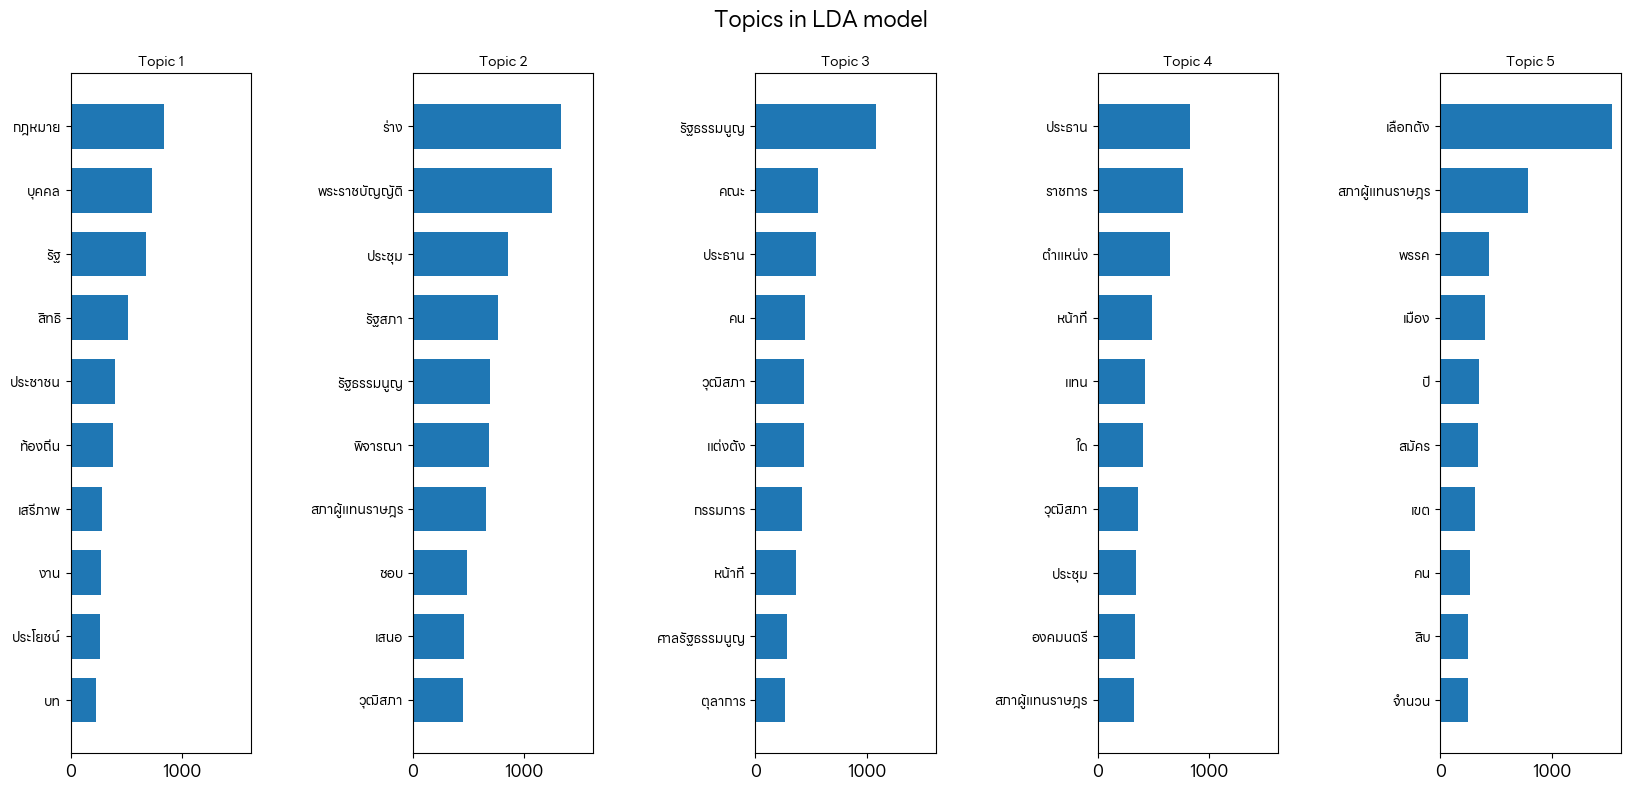

In [7]:
# Function to plot top words using matplotlib
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 5, figsize=(20, 8), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 14}, fontproperties=font_prop)
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
        
        # Use the custom Thai font for the labels
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.suptitle(title, fontsize=16, fontproperties=font_prop)
    plt.show()

print("Plotting top 10 words per topic in LDA:")
plot_top_words(lda_model, vectorizer.get_feature_names_out(), 10, "Topics in LDA model")


## 3. Topic Modeling with BERTopic
**BERTopic** is a newer model that uses deep learning (**Sentence Transformers**) to understand semantic meaning.

In [8]:
# 3.1 Setup BERTopic with Stronger Model and Fixed Data Type
from sklearn.feature_extraction.text import CountVectorizer

# 1. Use raw text for semantic meaning
docs_for_embeddings = df['text'].tolist()

# 2. Join tokens with spaces to satisfy BERTopic's string requirement
# This ensures words are counted correctly without the 'dump' character issue
docs_for_ctfidf = df['tokens'].apply(lambda x: ' '.join(x)).tolist()

# 3. Upgrade to the more powerful 'mpnet' model for better Thai understanding
print("Generating embeddings... (using multilingual-MPNet-base-v2)")
embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
embeddings = embedding_model.encode(docs_for_embeddings, show_progress_bar=True)

# 4. Vectorizer: Since words are now space-separated, we use a Thai-safe pattern
vectorizer_model = CountVectorizer(
    token_pattern=r"[\u0e00-\u0e7f]+",
    lowercase=False,
    stop_words=custom_stopwords
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

print("Training BERTopic...")
topics, probs = topic_model.fit_transform(docs_for_ctfidf, embeddings=embeddings)
print("Done!")


Generating embeddings... (using multilingual-MPNet-base-v2)


2026-05-02:12:31:28 WARNING  [huggingface_hub.utils._http:904] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9377.01it/s]
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 88/88 [00:37<00:00,  2.32it/s]
2026-05-02 12:32:14,514 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training BERTopic...


2026-05-02 12:32:25,995 - BERTopic - Dimensionality - Completed ✓
2026-05-02 12:32:25,995 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-02 12:32:26,057 - BERTopic - Cluster - Completed ✓
2026-05-02 12:32:26,060 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-02 12:32:26,122 - BERTopic - Representation - Completed ✓


Done!


In [9]:
# Let's look at the topics found by BERTopic
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))


,Topic,Count,Name,Representation,Representative_Docs
0,-1,377,-1_สรรหา_แต่งตั้ง_ชาติ_กรรมการ,"[สรรหา, แต่งตั้ง, ชาติ, กรรมการ, เมือง, แวดล้อ...",[สรรหา เลือก ประธาน กรรมการ กรรมการ การเลือกตั...
1,0,69,0_เขต_จังหวัด_เลือกตั้ง_ราษฎร,"[เขต, จังหวัด, เลือกตั้ง, ราษฎร, แบ่ง, สมัคร, ...",[เลือกตั้ง สมาชิก สภาผู้แทนราษฎร เลือกตั้ง แบ่...
2,1,54,1_ร้อง_ตีความ_วินิจฉัย_คณะตุลาการรัฐธรรมนูญ,"[ร้อง, ตีความ, วินิจฉัย, คณะตุลาการรัฐธรรมนูญ,...",[สมาชิก วุฒิสภา สมาชิก สภาผู้แทนราษฎร จำนวน สิ...
3,2,51,2_รัฐธรรมนูญ_ร่าง_ปฏิรูป_สภานิติบัญญัติแห่งชาติ,"[รัฐธรรมนูญ, ร่าง, ปฏิรูป, สภานิติบัญญัติแห่งช...",[สภานิติบัญญัติแห่งชาติ ร่าง รัฐธรรมนูญ คณะ กร...
4,3,47,3_ว่าง_อายุ_แทน_สลาก,"[ว่าง, อายุ, แทน, สลาก, วาระ, ตำแหน่ง, สมาชิกภ...",[ตำแหน่ง สมาชิก สภาผู้แทนราษฎร ว่าง ใด อายุ สภ...
5,4,42,4_เสรีภาพ_สิทธิ_เท่าเทียม_เสมอ,"[เสรีภาพ, สิทธิ, เท่าเทียม, เสมอ, บุคคล, ศักดิ...",[บุคคล เสมอ กฎหมาย คุ้มครอง กฎหมาย เท่าเทียม ช...
6,5,40,5_ประชุม_กรรมาธิการ_องค์_อนุโลม,"[ประชุม, กรรมาธิการ, องค์, อนุโลม, องค์ประชุม,...",[ประชุม รัฐสภา ข้อ บังคับ ประชุม รัฐสภา ข้อ บั...
7,6,38,6_ปฏิญาณ_พระพุทธเจ้า_สัตย์_จงรักภักดี,"[ปฏิญาณ, พระพุทธเจ้า, สัตย์, จงรักภักดี, ซื่อส...",[หน้าที่ รัฐมนตรี ถวาย สัตย์ ปฏิญาณ พระมหากษัต...
8,7,37,7_เอกราช_ทหาร_สถาบัน_วัฒนธรรม,"[เอกราช, ทหาร, สถาบัน, วัฒนธรรม, บูรณภาพ, การจ...",[รัฐ ทหาร พิทักษ์ รักษา เอกราช มั่นคง รัฐ สถาบ...
9,8,37,8_ศาลฎีกา_ตุลาการ_คุณวุฒิ_เลือก,"[ศาลฎีกา, ตุลาการ, คุณวุฒิ, เลือก, กรรมการ, สร...",[ศาลรัฐธรรมนูญ ประธาน ศาลรัฐธรรมนูญ คน ตุลาการ...


In [10]:
# Visualize the top words per topic as a bar chart (BERTopic natively supports Plotly)
fig = topic_model.visualize_barchart(top_n_topics=8)
fig


In [11]:
# Visualize the distance between topics
fig2 = topic_model.visualize_topics()
fig2


In [12]:
# 4. Advanced BERTopic Visualizations
# Visualize the hierarchical structure of topics
hierarchical_topics = topic_model.hierarchical_topics(docs_for_ctfidf)
fig_hierarchy = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig_hierarchy.show()

# Visualize Topic Heatmap (Similarity Matrix)
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.show()


100%|██████████| 117/117 [00:00<00:00, 1060.33it/s]
